In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve

# === CONFIG ===
CSV_PATH = "output/5_dec_data_z8/puncta_summary.csv"  # path to mean_intensity_and_puncta output
INTENSITY_COL = 'nuc_mean_raw'
PUNCTA_COL = "has_puncta"

# Binning for step curve
N_BINS = 20              # number of bins for empirical step curve

# Bootstrapping
BOOTSTRAP_ITERS = 1000
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

labels = {INTENSITY_COL:"Intensity", PUNCTA_COL:"Puncta status"}

In [2]:
df = pd.read_csv(CSV_PATH)
print("Columns:", df.columns.tolist())
print("Total cells:", len(df))

# Quick preview
df.head()

Columns: ['image_location', 'cyto_file', 'puncta_file', 'intensity_file', 'intensity_channel', 'cell_label', 'centroid_y', 'centroid_x', 'num_cyto_pixels', 'num_puncta_pixels', 'has_puncta', 'puncta_area_in_cell', 'puncta_density', 'background_method', 'background_value_global', 'norm_percentile', 'norm_value_pXX', 'local_bg_raw', 'local_bg_used', 'local_bg_source', 'local_bg_pixels_used', 'cyto_mean_raw', 'cyto_mean_bgsub', 'cyto_mean_norm', 'cyto_mean_bgsub_local', 'cyto_mean_norm_local', 'cyto_mean_bgsub_hybrid', 'sat_frac_cell', 'conc_estimate_hybrid', 'intensity_for_cs']
Total cells: 1184


,image_location,cyto_file,puncta_file,intensity_file,intensity_channel,cell_label,centroid_y,centroid_x,num_cyto_pixels,num_puncta_pixels,...,local_bg_pixels_used,cyto_mean_raw,cyto_mean_bgsub,cyto_mean_norm,cyto_mean_bgsub_local,cyto_mean_norm_local,cyto_mean_bgsub_hybrid,sat_frac_cell,conc_estimate_hybrid,intensity_for_cs
0,0_Z008,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2,1,260.623726,1926.166494,32758,293,...,3362,162.647690,28.647690,0.029143,33.647690,0.034230,33.647690,0.0,NaN,33.647690
1,0_Z008,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2,2,1196.994490,1783.749301,37571,0,...,3603,186.643311,52.643314,0.053554,31.643316,0.032191,31.643316,0.0,NaN,31.643316
2,0_Z008,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2,3,1678.108130,1874.859898,23333,0,...,2954,962.645325,828.645447,0.842976,529.645386,0.538805,529.645386,0.0,NaN,529.645386
3,0_Z008,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2,4,1818.119392,2036.318335,22514,0,...,2395,997.885254,863.885254,0.878825,549.885254,0.559395,549.885254,0.0,NaN,549.885254
4,0_Z008,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2,5,1965.806150,1180.527907,42373,1437,...,3774,297.576630,163.576645,0.166406,112.576637,0.114524,112.576637,0.0,NaN,112.576637


In [3]:
print(f"Cells: {len(df)}")

# Check class balance
print("Puncta label counts (0/1):")
print(df[PUNCTA_COL].value_counts())

Cells: 1184
Puncta label counts (0/1):
has_puncta
1    782
0    402
Name: count, dtype: int64


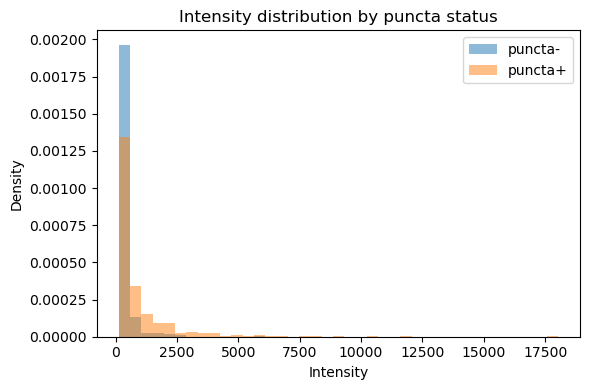

In [4]:
plt.figure(figsize=(6,4))

is_puncta = df[PUNCTA_COL] == 1
int_pos = df.loc[is_puncta, INTENSITY_COL].to_numpy()
int_neg = df.loc[~is_puncta, INTENSITY_COL].to_numpy()

bins = np.linspace(df[INTENSITY_COL].min(), df[INTENSITY_COL].max(), 40)

plt.hist(int_neg, bins=bins, alpha=0.5, label="puncta-", density=True)
plt.hist(int_pos, bins=bins, alpha=0.5, label="puncta+", density=True)

plt.xlabel(
labels[INTENSITY_COL])
plt.ylabel("Density")
plt.title("Intensity distribution by puncta status")
plt.legend()
plt.tight_layout()
plt.show()


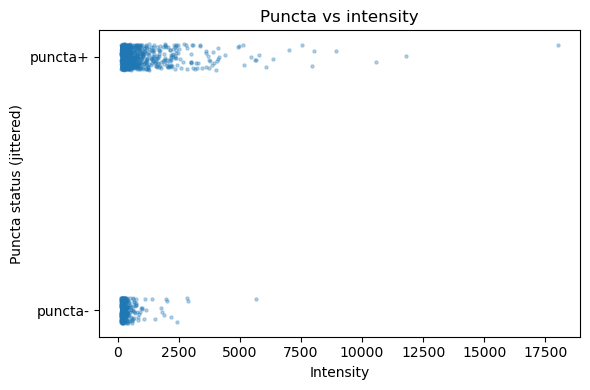

In [6]:
plt.figure(figsize=(6,4))

x = df[INTENSITY_COL].to_numpy()
y = df[PUNCTA_COL].to_numpy()

# jitter around 0 or 1 for visualization
np.random.seed(RANDOM_STATE)
y_jitter = y + (np.random.rand(len(y)) - 0.5) * 0.1

plt.scatter(x, y_jitter, s=5, alpha=0.3)
plt.yticks([0, 1], ["puncta-", "puncta+"])
plt.xlabel(labels[INTENSITY_COL])
plt.ylabel("Puncta status (jittered)")
plt.title("Puncta vs intensity")
plt.tight_layout()
plt.show()


In [12]:
labels

array([1, 0, 0, ..., 1, 1, 0])

In [14]:
# Define bins
bin_edges = np.linspace(df[INTENSITY_COL].min(),
                        df[INTENSITY_COL].max(),
                        N_BINS + 1)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_p = []  # fraction puncta+ in each bin
bin_n = []  # total cells per bin

intensity = df[INTENSITY_COL].to_numpy()
puncta_cols = df[PUNCTA_COL].to_numpy()

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (intensity >= lo) & (intensity < hi)
    n = in_bin.sum()
    bin_n.append(n)
    if n == 0:
        bin_p.append(np.nan)
    else:
        bin_p.append(puncta_cols[in_bin].mean())

bin_p = np.array(bin_p)
bin_n = np.array(bin_n)

# plt.figure(figsize=(6,4))
# plt.step(bin_centers, bin_p, where="mid")
# plt.scatter(bin_centers, bin_p, s=10)
# plt.ylim(-0.05, 1.05)
# plt.xlabel(INTENSITY_COL)
# plt.ylabel("P(puncta=1) (empirical)")
# plt.title("Empirical step curve")
# plt.tight_layout()
# plt.show()

# # Also show bin counts to see where you have data
# plt.figure(figsize=(6,3))
# plt.bar(bin_centers, bin_n, width=(bin_edges[1]-bin_edges[0]))
# plt.xlabel(INTENSITY_COL)
# plt.ylabel("# cells per bin")
# plt.title("Bin counts")
# plt.tight_layout()
# plt.show()


Unique labels in y: [0 1]
Logistic intercept (b0): -0.1707913402196342
Logistic slope (b1):     0.0017368070879064555
Estimated C_sat (intensity units): 98.3363906152098


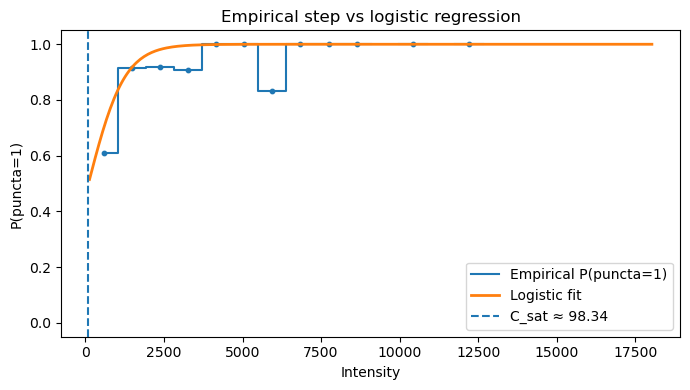

In [15]:
# Prepare data
X = intensity.reshape(-1, 1)
y = puncta_cols.astype(int)

# Basic sanity check
unique_labels = np.unique(y)
print("Unique labels in y:", unique_labels)
if len(unique_labels) < 2:
    raise ValueError("Need both puncta- and puncta+ cells to fit logistic regression.")

# Fit logistic regression with weak regularization
clf = LogisticRegression(
    solver="lbfgs",
    C=1e6,
    max_iter=1000,
    fit_intercept=True,
)
clf.fit(X, y)

b0 = clf.intercept_[0]
b1 = clf.coef_[0, 0]

print("Logistic intercept (b0):", b0)
print("Logistic slope (b1):    ", b1)

# C_sat = -b0 / b1 (intensity where P=0.5)
if np.isclose(b1, 0.0):
    csat = np.nan
    print("WARNING: Slope ~0, cannot define C_sat.")
else:
    csat = -b0 / b1
    print("Estimated C_sat (intensity units):", csat)

# Make smooth curve
x_grid = np.linspace(intensity.min(), intensity.max(), 300).reshape(-1,1)
p_grid = clf.predict_proba(x_grid)[:,1]

plt.figure(figsize=(7,4))

# empirical step
plt.step(bin_centers, bin_p, where="mid", label="Empirical P(puncta=1)")
plt.scatter(bin_centers, bin_p, s=10)

# logistic curve
plt.plot(x_grid.ravel(), p_grid, label="Logistic fit", linewidth=2)

# C_sat vertical line
if not np.isnan(csat):
    plt.axvline(csat, linestyle="--", label=f"C_sat ≈ {csat:.2f}")

plt.ylim(-0.05, 1.05)
plt.xlabel(labels[INTENSITY_COL])
plt.ylabel("P(puncta=1)")
plt.title("Empirical step vs logistic regression")
plt.legend()
plt.tight_layout()
plt.show()


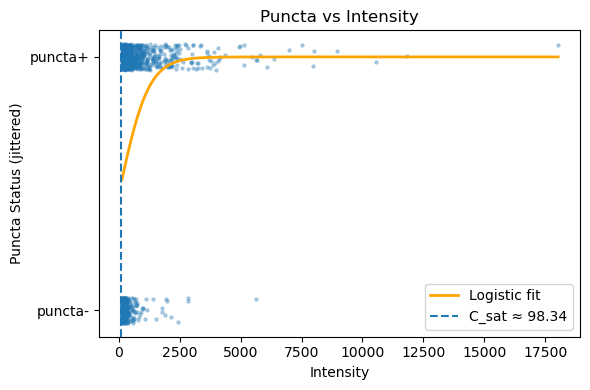

In [16]:
plt.figure(figsize=(6,4))

x = df[INTENSITY_COL].to_numpy()
y = df[PUNCTA_COL].to_numpy()

# jitter around 0 or 1 for visualization
y_jitter = y + (np.random.rand(len(y)) - 0.5) * 0.1

plt.plot(x_grid.ravel(), p_grid, label="Logistic fit", linewidth=2, color="orange")

# C_sat vertical line
if not np.isnan(csat):
    plt.axvline(csat, linestyle="--", label=f"C_sat ≈ {csat:.2f}")
    
plt.scatter(x, y_jitter, s=5, alpha=0.3)
plt.yticks([0, 1], ["puncta-", "puncta+"])
plt.xlabel(labels[INTENSITY_COL])
plt.ylabel("Puncta Status (jittered)")
plt.legend()
plt.title("Puncta vs Intensity")
plt.tight_layout()
plt.show()

In [ ]:
cols_to_show = [
    "image_location",
    "nucleus_label",
    INTENSITY_COL,
    "puncta_area_in_nuc",
    "puncta_density",
    "sat_frac_nuc",
    "num_cyto_pixels",
    "nuc_file",
    "puncta_file",
    "intensity_file",
    "centroid_y",
    "centroid_x",x
]

avail_cols = [c for c in cols_to_show if c in df.columns]

puncta_neg = df[df[PUNCTA_COL] == 0].copy()
puncta_neg_sorted = puncta_neg.sort_values(INTENSITY_COL)

print("Total puncta- cells:", len(puncta_neg_sorted))
puncta_neg_sorted[avail_cols].head(20)


Total puncta- cells: 402


,image_location,cell_label,cyto_mean_raw,puncta_area_in_cell,puncta_density,sat_frac_cell,num_cyto_pixels,puncta_file,intensity_file,centroid_y,centroid_x
258,13_Z008,2,138.073486,0,0.0,0.0,39895,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,470.728161,212.724527
151,125_Z008,1,138.081070,0,0.0,0.0,38291,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,307.737562,2085.038521
1031,75_Z008,1,138.754684,0,0.0,0.0,36463,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,101.883060,1737.066862
339,150_Z008,4,140.176331,0,0.0,0.0,27563,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,1193.259877,337.097595
697,23_Z008,1,141.228516,0,0.0,0.0,21421,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,63.602913,1158.227067
622,192_Z008,12,141.431931,0,0.0,0.0,22168,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,1742.437026,199.372519
1076,7_Z008,5,142.299500,0,0.0,0.0,21366,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2067.219414,380.833942
626,192_Z008,16,142.657669,0,0.0,0.0,38530,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2144.077965,389.761303
58,110_Z008,2,143.035461,0,0.0,0.0,26052,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,283.891371,164.174228
165,126_Z008,6,143.809143,0,0.0,0.0,39542,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,2025.12.05_HeLa P9_p944 1ug p893 1ug_Nucleus_0...,1798.303348,971.233322


In [ ]:
# Work on a copy sorted by intensity
df_sorted = df.sort_values(INTENSITY_COL).reset_index(drop=True)

# If there are no puncta+ cells, there is no C_sat
if (df_sorted[PUNCTA_COL] == 1).sum() == 0:
    csat_emp = None
    ok = False
    note = "No puncta-positive cells in data."
else:
    # 1) empirical candidate: smallest intensity with puncta+
    csat_emp = df_sorted.loc[df_sorted[PUNCTA_COL] == 1, INTENSITY_COL].iloc[0]

    # 2) sanity check: all cells strictly below this intensity must be puncta-
    below_mask = df_sorted[INTENSITY_COL] < csat_emp
    any_pos_below = (df_sorted.loc[below_mask, PUNCTA_COL] == 1).any()

    ok = not any_pos_below
    if ok:
        note = "OK: all cells below C_sat are puncta-."
    else:
        note = (
            "Sanity check FAILED: there exists at least one puncta+ cell "
            "with intensity < C_sat_emp."
        )

csat_emp, ok, note


(np.float64(131.7137451171875), True, 'OK: all cells below C_sat are puncta-.')